In [124]:
import sqlite3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

sns.set_theme(style="whitegrid")

In [125]:
# Connect to Optuna database
conn = sqlite3.connect("../results/studies/optuna_optimization_aleix.db")

# Check available tables
tables = pd.read_sql(
    "SELECT name FROM sqlite_master WHERE type='table';",
    conn
)
print("Available tables:")
print(tables)

# Load study information
studies = pd.read_sql("SELECT * FROM studies;", conn)
print("\nAvailable studies:")
print(studies)

Available tables:
                         name
0                     studies
1                version_info
2            study_directions
3       study_user_attributes
4     study_system_attributes
5                      trials
6       trial_user_attributes
7     trial_system_attributes
8                trial_params
9                trial_values
10  trial_intermediate_values
11           trial_heartbeats
12            alembic_version

Available studies:
   study_id        study_name
0         1  all_params_study


In [126]:
# Load trials, params and values
df_trials = pd.read_sql("SELECT * FROM trials WHERE study_id = (SELECT study_id FROM studies WHERE study_name = 'all_params_study');", conn)
df_params = pd.read_sql("SELECT * FROM trial_params WHERE trial_id IN (SELECT trial_id FROM trials WHERE study_id = (SELECT study_id FROM studies WHERE study_name = 'all_params_study'));", conn)
df_values = pd.read_sql("SELECT * FROM trial_values WHERE trial_id IN (SELECT trial_id FROM trials WHERE study_id = (SELECT study_id FROM studies WHERE study_name = 'all_params_study'));", conn)

conn.close()

print(f"Total trials: {len(df_trials)}")
print(f"Total recorded params: {len(df_params)}")
print(f"Total recorded values: {len(df_values)}")

Total trials: 67
Total recorded params: 402
Total recorded values: 65


In [127]:
# Pivot params to have one row per trial
df_params_pivot = df_params.pivot(
    index="trial_id",
    columns="param_name",
    values="param_value"
).reset_index()

df_params_pivot.columns.name = None

# Add mAP value
df_params_pivot = df_params_pivot.merge(df_values[["trial_id", "value"]], on="trial_id")
df_params_pivot.rename(columns={"value": "mAP"}, inplace=True)

# Convert mAP to percentage if necessary (assuming 0-1 scale is desired, or 0-100)
# Adjust based on your data range. If data is 0-100, divide by 100 for 0-1.
if df_params_pivot["mAP"].max() > 1:
    df_params_pivot["mAP"] = df_params_pivot["mAP"] / 100

# Convert numeric columns
numeric_cols = ['k', 'p', 'min_cc_pixels', 'open_morph', 'close_morph_x', 'close_morph_y']
for col in numeric_cols:
    if col in df_params_pivot.columns:
        df_params_pivot[col] = pd.to_numeric(df_params_pivot[col])

df_params_pivot.head()

,trial_id,close_morph_x,close_morph_y,k,min_cc_pixels,open_morph,p,mAP
0,2,34.0,52.0,3.227946,643.0,1.0,0.009522,0.244806
1,3,34.0,39.0,1.216677,398.0,8.0,0.005747,0.172171
2,4,20.0,48.0,2.516358,621.0,1.0,0.001179,0.069431
3,5,22.0,33.0,1.216714,682.0,8.0,0.007290,0.146550
4,6,33.0,60.0,2.433966,520.0,4.0,0.001423,0.560663


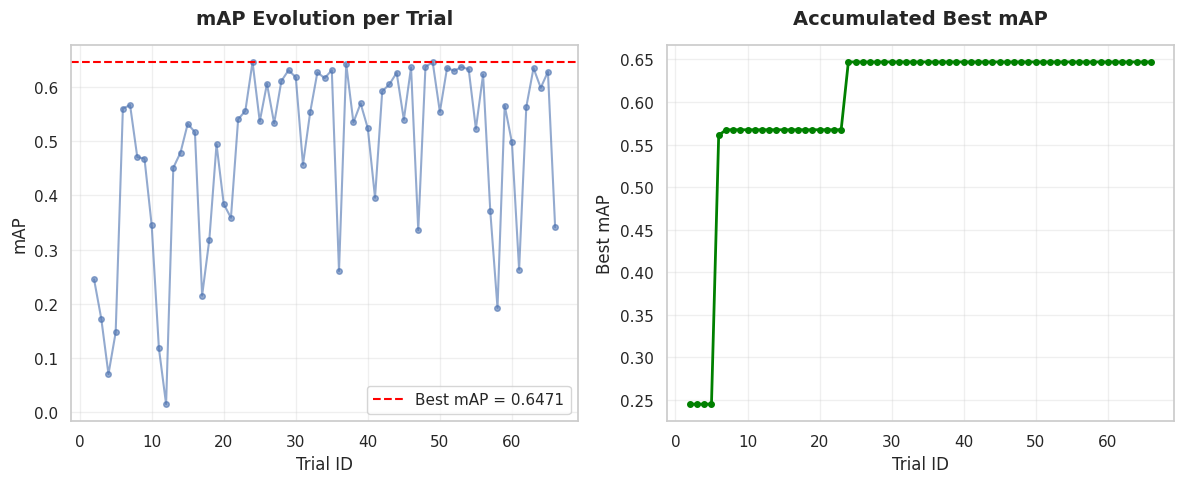

In [128]:
# 1. mAP Evolution per Trial
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(df_params_pivot["trial_id"], df_params_pivot["mAP"], marker='o', alpha=0.6, linestyle='-', markersize=4)
plt.axhline(df_params_pivot["mAP"].max(), color='red', linestyle='--', label=f'Best mAP = {df_params_pivot["mAP"].max():.4f}')
plt.title('mAP Evolution per Trial', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Trial ID', fontsize=12)
plt.ylabel('mAP', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
cummax = df_params_pivot["mAP"].cummax()
plt.plot(df_params_pivot["trial_id"], cummax, marker='o', color='green', linewidth=2, markersize=4)
plt.title('Accumulated Best mAP', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Trial ID', fontsize=12)
plt.ylabel('Best mAP', fontsize=12)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

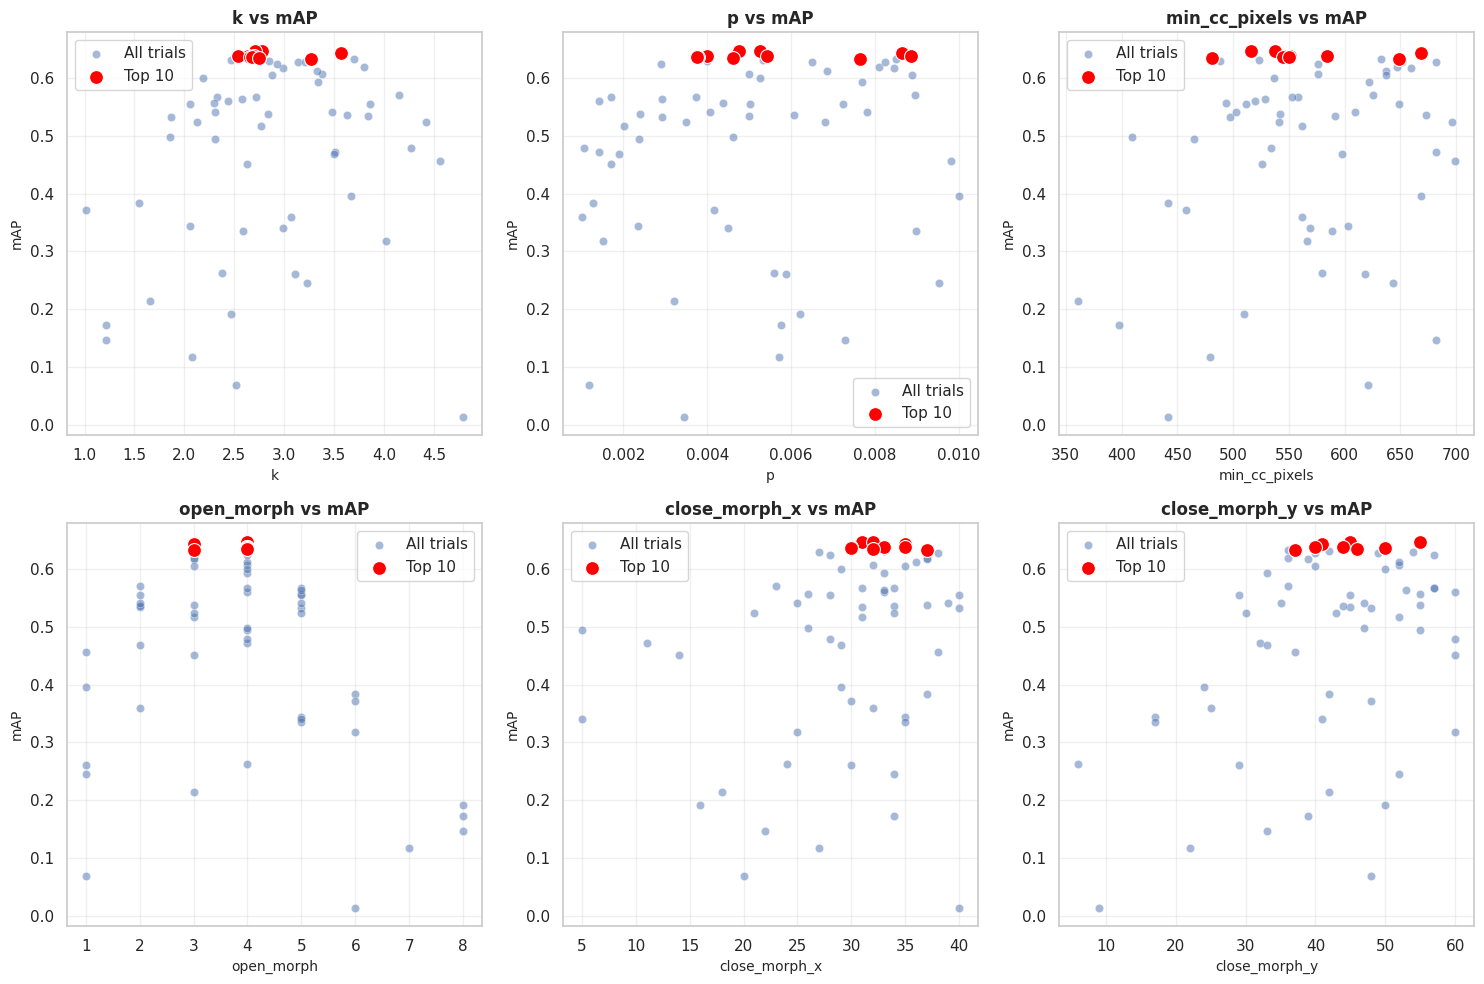

In [129]:
# 2. Hyperparameter Distribution for Top 10 Trials
top_n = 10
top_trials = df_params_pivot.nlargest(top_n, 'mAP')

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

params_to_plot = ['k', 'p', 'min_cc_pixels', 'open_morph', 'close_morph_x', 'close_morph_y']

for idx, param in enumerate(params_to_plot):
    if param in top_trials.columns:
        ax = axes[idx]
        sns.scatterplot(data=df_params_pivot, x=param, y='mAP', alpha=0.5, ax=ax, label='All trials')
        sns.scatterplot(data=top_trials, x=param, y='mAP', color='red', s=100, ax=ax, label=f'Top {top_n}')
        ax.set_title(f'{param} vs mAP', fontsize=12, fontweight='bold')
        ax.set_xlabel(param, fontsize=10)
        ax.set_ylabel('mAP', fontsize=10)
        ax.legend()
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

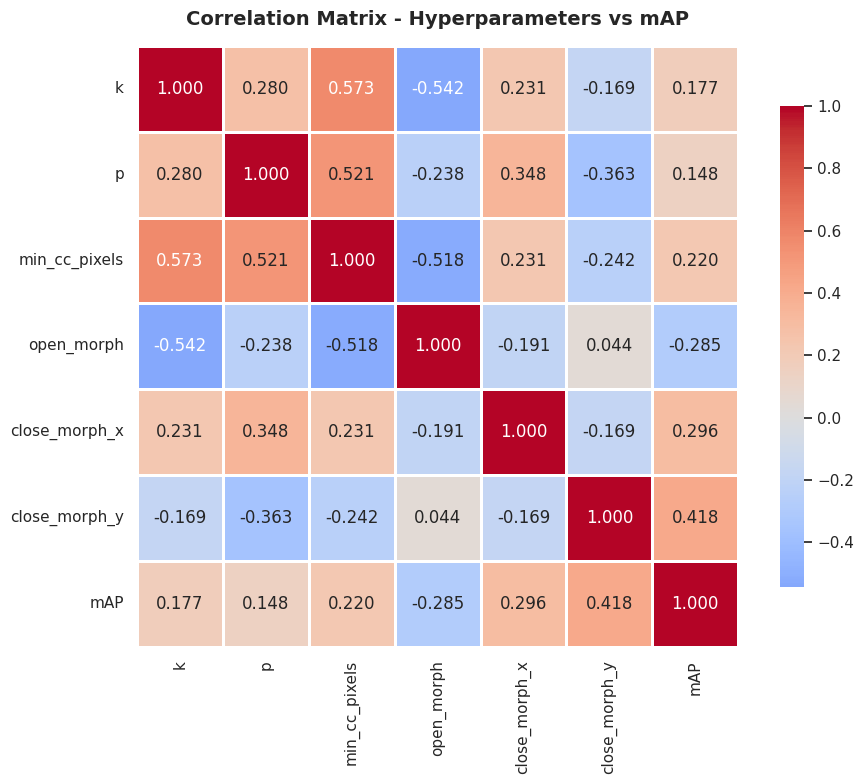

In [130]:
# 3. Correlation Matrix - Hyperparameters vs mAP
correlation_cols = ['k', 'p', 'min_cc_pixels', 'open_morph', 'close_morph_x', 'close_morph_y', 'mAP']
available_cols = [col for col in correlation_cols if col in df_params_pivot.columns]

plt.figure(figsize=(10, 8))
correlation_matrix = df_params_pivot[available_cols].corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix - Hyperparameters vs mAP', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

In [ ]:
# 4. Analysis of k vs p (3D Surface Plot - Animated GIF)
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.tri as tri
import matplotlib.animation as animation
from IPython.display import Image

# Filter data
x = df_params_pivot["k"]
y = df_params_pivot["p"]
z = df_params_pivot["mAP"]

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Create triangulation for surface plot
triang = tri.Triangulation(x, y)

# Plot the surface
surf = ax.plot_trisurf(triang, z, cmap='viridis', linewidth=0.2, antialiased=True, alpha=0.8)

# Add color bar
cbar = fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)
cbar.set_label('mAP')

# Labels and title
ax.set_title('3D Visualization: Alpha vs Rho', fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Alpha', fontsize=12, labelpad=10)
ax.set_ylabel('Rho', fontsize=12, labelpad=10)
ax.set_zlabel('mAP', fontsize=12, labelpad=10)

def rotate(angle):
    ax.view_init(elev=30, azim=angle)

print("Generating animation...")
ani = animation.FuncAnimation(fig, rotate, frames=np.arange(0, 360, 2), interval=50)
ani.save('k_p_map_3d_rotation.gif', writer='pillow', fps=20)
plt.close()

print("Animation saved as 'k_p_map_3d_rotation.gif'")
Image(filename="k_p_map_3d_rotation.gif")

Generating animation...
